# Category: Crime
We will conduct our exploratory data analysis for this category using selected variables. Then we will create a scoring system using PCA. Finally, we will validate our results using real migration data.

# Setup

In [ ]:
import os
import sys
import math
import json
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("crime_per_capita_wide.csv")

In [ ]:
df

,State_FIPS,County_FIPS,FIPS_5digit,State,County,Population_2020,Population_2021,Population_2022,Population_2023,Population_2024,Violent_Crime_2020,Violent_Crime_2021,Violent_Crime_2022,Violent_Crime_2023,Violent_Crime_2024,Property_Crime_2020,Property_Crime_2021,Property_Crime_2022,Property_Crime_2023,Property_Crime_2024,Violent_Crime_Rate_2020,Violent_Crime_Rate_2021,Violent_Crime_Rate_2022,Violent_Crime_Rate_2023,Violent_Crime_Rate_2024,Property_Crime_Rate_2020,Property_Crime_Rate_2021,Property_Crime_Rate_2022,Property_Crime_Rate_2023,Property_Crime_Rate_2024,Population_Avg,Violent_Crime_Avg,Property_Crime_Avg,Violent_Crime_Rate_Avg,Property_Crime_Rate_Avg
0,1.0,1.0,1001.0,Alabama,Autauga,58914.0,59207.0,59755.0,60502.0,61476.0,59.0,62.0,62.0,47.0,54.0,267.0,265.0,228.0,220.0,221.0,100.15,104.72,103.76,77.68,87.84,453.20,447.58,381.56,363.62,359.49,59970.80,56.8,240.2,94.83,401.09
1,1.0,19.0,1019.0,Alabama,Cherokee,24978.0,25056.0,25318.0,25650.0,26088.0,67.0,71.0,52.0,64.0,49.0,313.0,339.0,280.0,308.0,264.0,268.24,283.37,205.39,249.51,187.83,1253.10,1352.97,1105.93,1200.78,1011.96,25418.00,60.6,300.8,238.87,1184.95
2,1.0,25.0,1025.0,Alabama,Clarke,22982.0,22732.0,22541.0,22336.0,22127.0,42.0,63.0,35.0,62.0,36.0,53.0,99.0,95.0,92.0,73.0,182.75,277.14,155.27,277.58,162.70,230.62,435.51,421.45,411.89,329.91,22543.60,47.6,82.4,211.09,365.88
3,1.0,91.0,1091.0,Alabama,Marengo,19266.0,18974.0,18789.0,18672.0,NaN,26.0,7.0,13.0,18.0,NaN,88.0,38.0,52.0,42.0,NaN,134.95,36.89,69.19,96.40,NaN,456.76,200.27,276.76,224.94,NaN,18925.25,16.0,55.0,84.36,289.68
4,4.0,15.0,4015.0,Arizona,Mohave,214167.0,217232.0,220791.0,223586.0,226262.0,153.0,246.0,263.0,182.0,206.0,1637.0,1649.0,1599.0,1428.0,1335.0,71.44,113.24,119.12,81.40,91.04,764.36,759.10,724.21,638.68,590.02,220407.60,210.0,1529.6,95.25,695.27


## Initial profiling

We have the following variables according to years.

| Variable | Explanation |
| --- | --- |
| Population | County population from U.S. Census Bureau annual estimates. |
| Violent_Crime | Raw count of violent crimes reported to law enforcement (murder, rape, robbery, aggravated assault). |
| Property_Crime | Raw count of property crimes reported to law enforcement (burglary, larceny-theft, motor vehicle theft). |
| Violent_Crime_Rate | Violent crimes per 100,000 inhabitants. |
| Property_Crime_Rate | Property crimes per 100,000 inhabitants. |

In [ ]:
print('Rows:', len(df), 'Columns:', df.shape[1])
display(df.drop(columns=['State_FIPS','County_FIPS','FIPS_5digit','State','County']).describe(include='all').T)

Rows: 2962 Columns: 35


,count,mean,std,min,25%,50%,75%,max
Population_2020,2195.0,103742.474715,354033.749128,63.0,11892.0000,26613.000,67814.0000,9996510.00
Population_2021,1956.0,76159.763804,201917.713725,57.0,11859.5000,25525.500,60570.2500,4736539.00
Population_2022,2202.0,97105.263851,322611.620050,46.0,12031.0000,26785.000,67351.2500,9748524.00
Population_2023,2321.0,100743.813442,333764.526831,46.0,12580.0000,28083.000,70331.0000,9732568.00
Population_2024,2400.0,109791.760833,345128.858656,47.0,12996.2500,29351.000,77952.5000,9748868.00
Violent_Crime_2020,2196.0,82.795993,333.346769,0.0,7.0000,21.000,57.0000,8813.00
Violent_Crime_2021,1957.0,62.181911,251.242326,0.0,7.0000,21.000,54.0000,9487.00
Violent_Crime_2022,2204.0,72.990472,298.574123,0.0,7.0000,22.000,56.0000,9199.00
Violent_Crime_2023,2324.0,69.965577,296.786530,0.0,7.0000,21.000,55.0000,10173.00
Violent_Crime_2024,2402.0,72.674438,276.122225,0.0,7.0000,20.000,53.0000,7666.00


## Missingness analysis

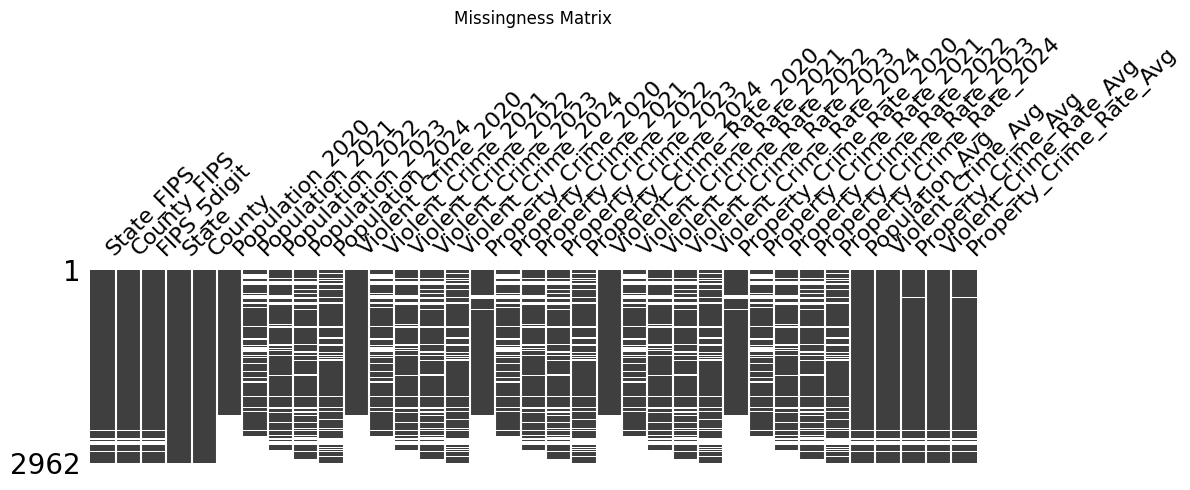

In [ ]:
import missingno as msno
msno.matrix(df)
plt.show()

We notice that some rows have missing data. This is primarily due to counties that did not report crime data to the FBI in a given year, which is common in the Uniform Crime Reporting program.

In [ ]:
missing_fraction = df.isna().mean(axis=1)
rows_missing_data = df[missing_fraction > 0.90]
print('Total number of counties missing more than 90% of data is ' + str(len(rows_missing_data)))
display(rows_missing_data[['FIPS_5digit', 'State', 'County']])

Total number of counties missing more than 90% of data is 180


,FIPS_5digit,State,County
181,NaN,Delaware,New Castle County Police Department
258,NaN,Georgia,Clayton County Police Department
260,NaN,Georgia,Cobb County Police Department
264,NaN,Georgia,Dougherty County Police Department
270,NaN,Georgia,Floyd County Police Department
331,NaN,Georgia,Polk County Police Department
583,NaN,Kansas,Riley County Police Department
655,NaN,Kentucky,Campbell County Police Department
672,NaN,Kentucky,Kenton County Police Department
677,NaN,Kentucky,Oldham County Police Department


These are counties that did not report crime data for almost any year covered. They will be excluded from the analysis.

In [ ]:
missing_fraction_cols = df.isna().mean(axis=0)
worst_col = missing_fraction_cols.idxmax()
print("Column with most missing data:", worst_col)
print("Missing percent:", missing_fraction_cols[worst_col] * 100)
print("Missing count:", df[worst_col].isna().sum())

Column with most missing data: Population_2021
Missing percent: 33.96
Missing count: 1006


We will still keep these variables as missing since the percentage of missing values is not high enough to justify dropping the column. FBI non-reporting is a known data limitation and missing values will be imputed with the median during PCA scoring.

In [ ]:
df_new = df[missing_fraction <= 0.90]

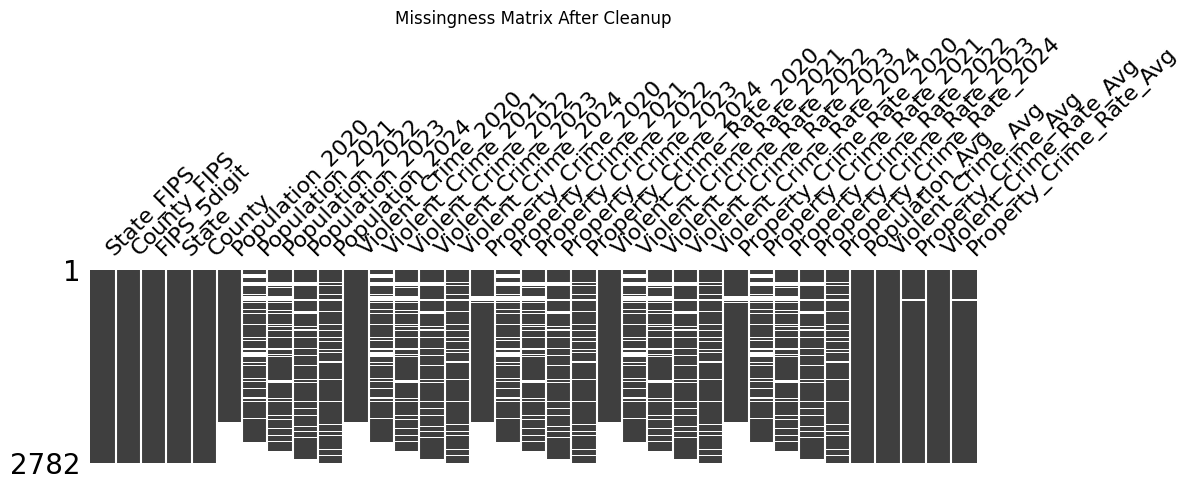

In [ ]:
msno.matrix(df_new)
plt.show()

## Ranges and Impossible Values
Now, let's carefully check the ranges and possible outliers for our variables.

In [ ]:
population_cols = [
    "Population_2020",
    "Population_2021",
    "Population_2022",
    "Population_2023",
    "Population_2024"
]
bad_population = df_new[df_new[population_cols].lt(0).any(axis=1)]
print("Number of impossible Population values (negative):", len(bad_population))
if len(bad_population) == 0:
    print("No impossible values found.")
else:
    display(bad_population[['FIPS_5digit', 'State', 'County'] + population_cols])

Number of impossible Population values (negative): 0
No impossible values found.


In [ ]:
violent_crime_cols = [
    "Violent_Crime_2020",
    "Violent_Crime_2021",
    "Violent_Crime_2022",
    "Violent_Crime_2023",
    "Violent_Crime_2024"
]
bad_violent_crime = df_new[df_new[violent_crime_cols].lt(0).any(axis=1)]
print("Number of impossible Violent_Crime values (negative):", len(bad_violent_crime))
if len(bad_violent_crime) == 0:
    print("No impossible values found.")
else:
    display(bad_violent_crime[['FIPS_5digit', 'State', 'County'] + violent_crime_cols])

Number of impossible Violent_Crime values (negative): 0
No impossible values found.


In [ ]:
property_crime_cols = [
    "Property_Crime_2020",
    "Property_Crime_2021",
    "Property_Crime_2022",
    "Property_Crime_2023",
    "Property_Crime_2024"
]
bad_property_crime = df_new[df_new[property_crime_cols].lt(0).any(axis=1)]
print("Number of impossible Property_Crime values (negative):", len(bad_property_crime))
if len(bad_property_crime) == 0:
    print("No impossible values found.")
else:
    display(bad_property_crime[['FIPS_5digit', 'State', 'County'] + property_crime_cols])

Number of impossible Property_Crime values (negative): 0
No impossible values found.


In [ ]:
violent_crime_rate_cols = [
    "Violent_Crime_Rate_2020",
    "Violent_Crime_Rate_2021",
    "Violent_Crime_Rate_2022",
    "Violent_Crime_Rate_2023",
    "Violent_Crime_Rate_2024"
]
bad_violent_crime_rate = df_new[df_new[violent_crime_rate_cols].lt(0).any(axis=1)]
print("Number of impossible Violent_Crime_Rate values (negative):", len(bad_violent_crime_rate))
if len(bad_violent_crime_rate) == 0:
    print("No impossible values found.")
else:
    display(bad_violent_crime_rate[['FIPS_5digit', 'State', 'County'] + violent_crime_rate_cols])

Number of impossible Violent_Crime_Rate values (negative): 0
No impossible values found.


In [ ]:
property_crime_rate_cols = [
    "Property_Crime_Rate_2020",
    "Property_Crime_Rate_2021",
    "Property_Crime_Rate_2022",
    "Property_Crime_Rate_2023",
    "Property_Crime_Rate_2024"
]
bad_property_crime_rate = df_new[df_new[property_crime_rate_cols].lt(0).any(axis=1)]
print("Number of impossible Property_Crime_Rate values (negative):", len(bad_property_crime_rate))
if len(bad_property_crime_rate) == 0:
    print("No impossible values found.")
else:
    display(bad_property_crime_rate[['FIPS_5digit', 'State', 'County'] + property_crime_rate_cols])

Number of impossible Property_Crime_Rate values (negative): 0
No impossible values found.


## Duplicates

In [ ]:
dup_rows = df_new.duplicated(keep=False)
print('Duplicate rows:', dup_rows.sum())

Duplicate rows: 0


## Profiling After Cleanup

In [ ]:
display(df_new[pop_cols].describe().T)
display(df_new[vc_cols].describe().T)
display(df_new[pc_cols].describe().T)
display(df_new[vcr_cols].describe().T)
display(df_new[pcr_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Population_2020,2195.0,103742.474715,354033.749128,63.0,11892.00,26613.0,67814.00,9996510.0
Population_2021,1956.0,76159.763804,201917.713725,57.0,11859.50,25525.5,60570.25,4736539.0
Population_2022,2202.0,97105.263851,322611.620050,46.0,12031.00,26785.0,67351.25,9748524.0
Population_2023,2321.0,100743.813442,333764.526831,46.0,12580.00,28083.0,70331.00,9732568.0
Population_2024,2400.0,109791.760833,345128.858656,47.0,12996.25,29351.0,77952.50,9748868.0


,count,mean,std,min,25%,50%,75%,max
Violent_Crime_2020,2196.0,82.795993,333.346769,0.0,7.0,21.0,57.0,8813.0
Violent_Crime_2021,1957.0,62.181911,251.242326,0.0,7.0,21.0,54.0,9487.0
Violent_Crime_2022,2204.0,72.990472,298.574123,0.0,7.0,22.0,56.0,9199.0
Violent_Crime_2023,2324.0,69.965577,296.786530,0.0,7.0,21.0,55.0,10173.0
Violent_Crime_2024,2402.0,72.674438,276.122225,0.0,7.0,20.0,53.0,7666.0


,count,mean,std,min,25%,50%,75%,max
Property_Crime_2020,2108.0,395.366224,1456.157402,0.0,37.00,111.5,291.25,43757.0
Property_Crime_2021,1957.0,302.118549,1182.737735,0.0,38.00,104.0,257.00,44391.0
Property_Crime_2022,2204.0,334.032668,1381.455260,0.0,33.00,101.0,263.25,50747.0
Property_Crime_2023,2324.0,298.109294,1323.316073,0.0,29.00,85.0,223.00,50545.0
Property_Crime_2024,2402.0,292.900916,1157.959878,0.0,25.25,76.0,200.00,33050.0


,count,mean,std,min,25%,50%,75%,max
Violent_Crime_Rate_2020,2193.0,115.041619,145.323176,0.0,33.5900,74.640,147.7500,3174.60
Violent_Crime_Rate_2021,1956.0,113.440542,164.821618,0.0,37.1525,75.295,144.2925,5263.16
Violent_Crime_Rate_2022,2202.0,111.711490,125.091878,0.0,34.3975,75.675,145.9325,1467.67
Violent_Crime_Rate_2023,2321.0,104.052637,115.343289,0.0,30.9000,68.860,136.4200,1097.20
Violent_Crime_Rate_2024,2400.0,98.210892,110.718316,0.0,28.2400,68.490,131.7225,1832.57


,count,mean,std,min,25%,50%,75%,max
Property_Crime_Rate_2020,2107.0,540.321542,700.192471,0.0,217.985,424.330,719.3650,25396.83
Property_Crime_Rate_2021,1956.0,518.363722,792.214770,0.0,210.200,397.660,675.7725,29824.56
Property_Crime_Rate_2022,2202.0,489.511866,1137.270515,0.0,191.190,358.445,631.2500,50000.00
Property_Crime_Rate_2023,2321.0,427.658518,1396.626330,0.0,158.970,309.080,537.1600,65217.39
Property_Crime_Rate_2024,2400.0,383.766908,1508.307653,0.0,129.740,269.890,481.5325,72340.43


## Correlation Between Variables

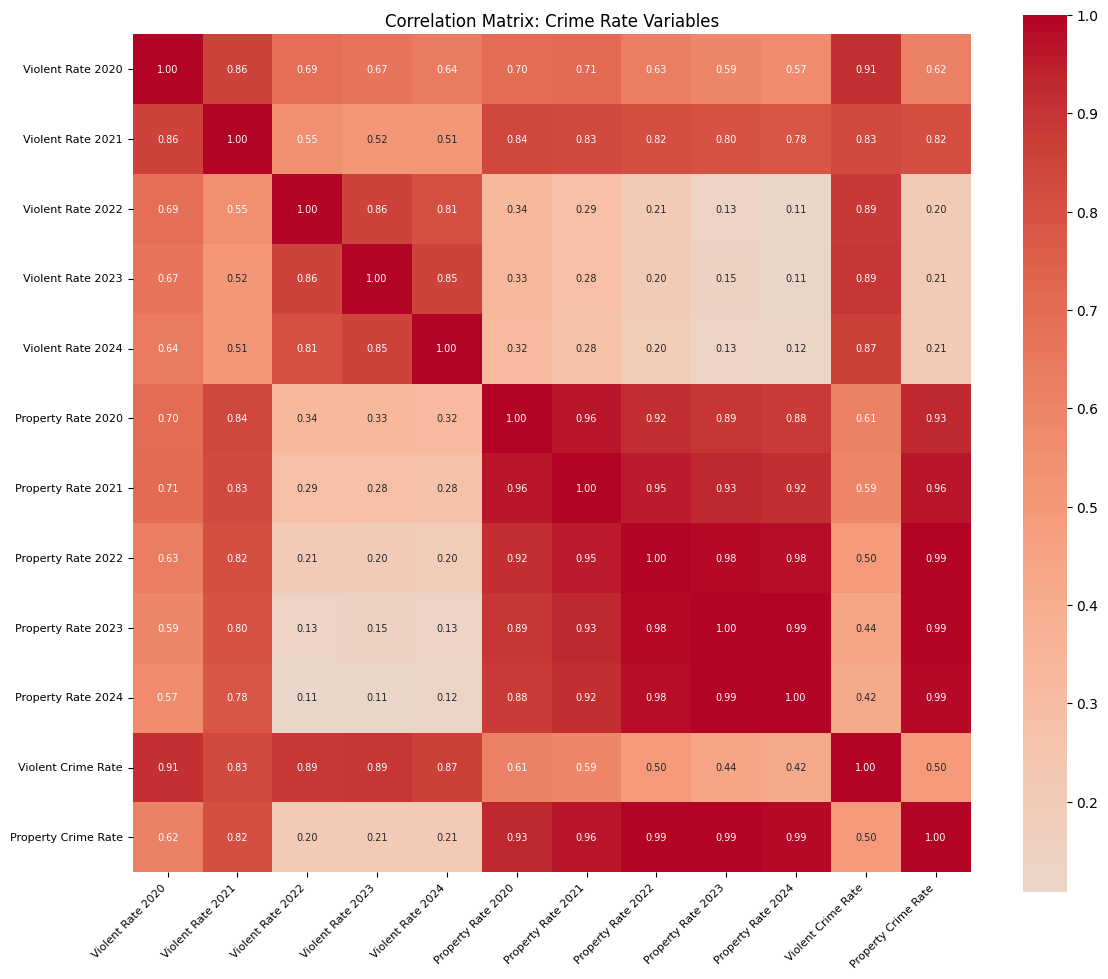

In [ ]:
import seaborn as sns

rate_cols = vcr_cols + pcr_cols + avg_cols
short_names = {
    'Violent_Crime_Rate_Avg':  'Violent Rate Avg',
    'Property_Crime_Rate_Avg': 'Property Rate Avg',
    **{f'Violent_Crime_Rate_{y}':  f'Violent Rate {y}'  for y in range(2020,2025)},
    **{f'Property_Crime_Rate_{y}': f'Property Rate {y}' for y in range(2020,2025)},
}
corr = df_new[rate_cols].corr().rename(index=short_names, columns=short_names)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True,
            annot_kws={"size": 7})
ax.set_title("Correlation Matrix: Crime Rate Variables")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

Crime rates show strong year-over-year stability within each crime type — the correlation between Violent Crime Rate 2020 and 2024 is approximately 0.64, and similarly 0.88 for Property Crime Rate. This suggests that a county's relative crime level is persistent over time.

The correlation between Violent Crime Rate and Property Crime Rate (≈0.50) is moderate, suggesting that while high-crime counties tend to have elevated rates of both types, the two dimensions capture somewhat distinct aspects of public safety and both are worth retaining in the PCA.

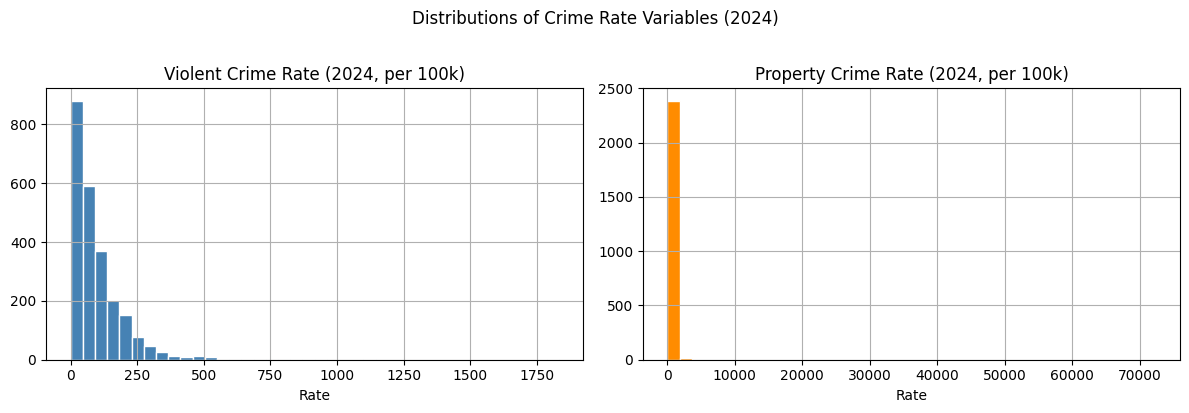

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_new['Violent_Crime_Rate_2024'].dropna().hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Violent Crime Rate (2024, per 100k)")
axes[0].set_xlabel("Rate per 100,000")
df_new['Property_Crime_Rate_2024'].dropna().hist(bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title("Property Crime Rate (2024, per 100k)")
axes[1].set_xlabel("Rate per 100,000")
plt.suptitle("Distributions of Crime Rate Variables (2024)", y=1.02)
plt.tight_layout(); plt.show()

## Visualization of Data
This section will visualize crime rate variables and their changes over the years.

In [ ]:
import plotly.express as px

def violent_crime_trend(state_name):
    vcr_cols = [f'Violent_Crime_Rate_{y}' for y in range(2020, 2025)]
    df_state = df_new[df_new['State'].str.title() == state_name.title()].copy()
    if df_state.empty:
        print(f"No data found for state: {state_name}"); return
    df_long = df_state.melt(
        id_vars=['FIPS_5digit', 'State', 'County'],
        value_vars=vcr_cols, var_name='variable_year', value_name='Violent_Crime_Rate'
    )
    df_long['year'] = df_long['variable_year'].str.extract(r'(\d{4})').astype(int)
    state_trend = df_long.groupby('year', as_index=False)['Violent_Crime_Rate'].mean()
    fig = px.line(
        state_trend, x='year', y='Violent_Crime_Rate', markers=True,
        title=f'Average Violent Crime Rate in {state_name.title()}, 2020–2024',
        labels={'year': 'Year', 'Violent_Crime_Rate': 'Violent Crime Rate (per 100k)'}
    )
    fig.show()

In [ ]:
# You can use this function to see violent crime rate trends by entering the full state name.
violent_crime_trend('Florida')

In [ ]:
import plotly.express as px

def property_crime_box(state_name):
    pcr_cols = [f'Property_Crime_Rate_{y}' for y in range(2020, 2025)]
    df_state = df_new[df_new['State'].str.title() == state_name.title()].copy()
    if df_state.empty:
        print(f"No data found for state: {state_name}"); return
    df_long = df_state.melt(
        id_vars=['FIPS_5digit', 'State', 'County'],
        value_vars=pcr_cols, var_name='variable_year', value_name='Property_Crime_Rate'
    )
    df_long['year'] = df_long['variable_year'].str.extract(r'(\d{4})').astype(int)
    df_long = df_long.dropna(subset=['Property_Crime_Rate'])
    fig = px.box(
        df_long, x='year', y='Property_Crime_Rate', points='all', hover_name='County',
        title=f'Distribution of Property Crime Rate in {state_name.title()}',
        labels={'year': 'Year', 'Property_Crime_Rate': 'Property Crime Rate (per 100k)'}
    )
    fig.show()

In [ ]:
# You can use this function to see property crime rate distribution by entering the full state name.
property_crime_box('Texas')

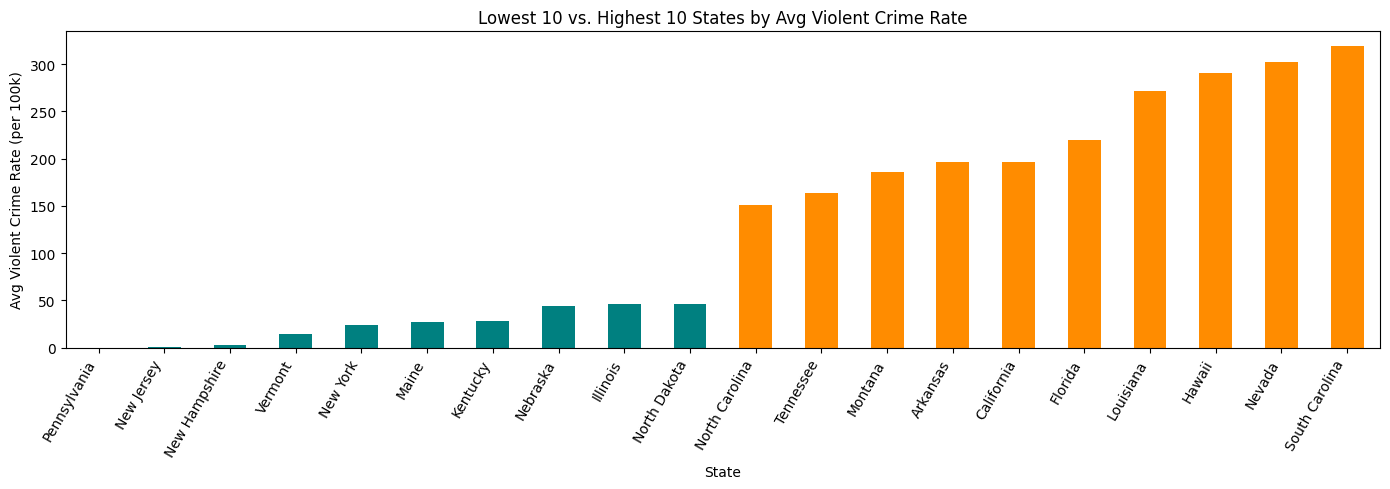

In [ ]:
state_vcr = (
    df_new.groupby('State')['Violent_Crime_Rate_Avg'].mean().dropna().sort_values()
)
state_vcr_extremes = pd.concat([state_vcr.head(10), state_vcr.tail(10)])
fig, ax = plt.subplots(figsize=(14, 5))
state_vcr_extremes.plot(kind='bar', ax=ax, color=(['teal'] * 10 + ['darkorange'] * 10))
ax.set_title("Lowest 10 vs. Highest 10 States by Avg Violent Crime Rate")
ax.set_ylabel("Avg Violent Crime Rate (per 100k)")
ax.set_xlabel("State")
plt.xticks(rotation=60, ha='right'); plt.tight_layout(); plt.show()

# Scoring using PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_cols = [
    'FIPS_5digit', 'State_FIPS', 'County_FIPS', 'State', 'County',
    'Violent_Crime_Rate_Avg',
    'Property_Crime_Rate_Avg'
]
pca_df = df_new[pca_cols].copy()
score_cols = pca_cols[5:]

# Fill missing values with median
for col in score_cols:
    pca_df[col] = pca_df[col].fillna(pca_df[col].median())

# Reverse both variables: higher crime rate = worse, so we negate to make higher = better
pca_df['Violent_Crime_Rate_Avg']  = -pca_df['Violent_Crime_Rate_Avg']
pca_df['Property_Crime_Rate_Avg'] = -pca_df['Property_Crime_Rate_Avg']

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df[score_cols])

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(pca_scaled)

pca.components_, pca.explained_variance_ratio_

(array([[0.7071067811865476, 0.7071067811865475], [-0.7071067811865475, 0.7071067811865476]]),
 array([0.7476101119041548, 0.252389888095845]))

PC1 accounts for 74.8% of the variance. Let's inspect the loadings:

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=score_cols
)
display(loadings)

,PC1,PC2
Violent_Crime_Rate_Avg,0.707107,-0.707107
Property_Crime_Rate_Avg,0.707107,0.707107


Since both variables were negated before PCA, PC1 now points in the direction of lower crime rates, capturing the overall public safety level of a county. A higher PC1 means both lower violent and lower property crime rates.

PC2 captures the tension between the two crime types — counties that rank very differently on violent vs. property crime. With 74.8% of variance explained by PC1, the two crime dimensions are highly aligned, which makes the composite score a reliable summary of overall public safety.

In [ ]:
pca_df['PC1'] = pca_scores[:, 0]

pca_df['Crime Score'] = (
    100 * (pca_df['PC1'] - pca_df['PC1'].min()) /
    (pca_df['PC1'].max() - pca_df['PC1'].min())
)

df_scores = pca_df.sort_values(by='Crime Score', ascending=False)[
    ['FIPS_5digit', 'State_FIPS', 'County_FIPS', 'State', 'County', 'Crime Score']
]
display(df_scores)
df_scores.to_csv("Crime Score by County.csv", index=False)

,FIPS_5digit,State_FIPS,County_FIPS,State,County,Crime Score
2874,42015.0,42.0,15.0,Pennsylvania,Bradford,100.000000
2876,42085.0,42.0,85.0,Pennsylvania,Mercer,100.000000
2875,42059.0,42.0,59.0,Pennsylvania,Greene,100.000000
2877,42097.0,42.0,97.0,Pennsylvania,Northumberland,100.000000
2863,42001.0,42.0,1.0,Pennsylvania,Adams,100.000000
2273,13059.0,13.0,59.0,Georgia,Clarke,100.000000
2881,42117.0,42.0,117.0,Pennsylvania,Tioga,100.000000
2883,42127.0,42.0,127.0,Pennsylvania,Wayne,100.000000
2882,42119.0,42.0,119.0,Pennsylvania,Union,100.000000
1209,34023.0,34.0,23.0,New Jersey,Middlesex,100.000000


# Validation

Now our goal is to check if the counties with higher Crime Scores (lower crime) have higher migration rates.

## Correlation between Crime Scores and Migration Rates
We have migration data by county for the last three years. We want to use average migration rates (per 1000 people). We will examine domestic, international, and total migrations.

In [ ]:
scores_df = pd.read_csv("Crime Score by County.csv")
migration_df = pd.read_csv("Migration_Rates_by_County.csv")

migration_df['avg_net_domestic_migration_rate']      = migration_df[['RDOMESTICMIG2023','RDOMESTICMIG2024','RDOMESTICMIG2025']].mean(axis=1)
migration_df['avg_net_international_migration_rate'] = migration_df[['RINTERNATIONALMIG2023','RINTERNATIONALMIG2024','RINTERNATIONALMIG2025']].mean(axis=1)
migration_df['avg_net_total_migration_rate']         = migration_df[['RNETMIG2023','RNETMIG2024','RNETMIG2025']].mean(axis=1)

scores_df['FIPS_int'] = pd.to_numeric(scores_df['FIPS_5digit'], errors='coerce').astype('Int64')
migration_df['FIPS_int'] = migration_df['FIPS'].astype(int)

validation_df = scores_df.merge(
    migration_df[['FIPS_int','avg_net_domestic_migration_rate',
                  'avg_net_international_migration_rate','avg_net_total_migration_rate']],
    on='FIPS_int', how='left'
)
validation_df = validation_df.dropna(subset=['Crime Score','avg_net_domestic_migration_rate'])
display(validation_df.sample(5))

,FIPS_5digit,State_FIPS,County_FIPS,State,County,Crime Score,FIPS_int,avg_net_domestic_migration_rate,avg_net_international_migration_rate,avg_net_total_migration_rate
1804,40117.0,40.0,117.0,Oklahoma,Pawnee,97.733487,40117,13.404841,0.209002,13.613843
2164,47107.0,47.0,107.0,Tennessee,McMinn,96.943974,47107,18.693986,0.772659,19.466645
1456,39139.0,39.0,139.0,Ohio,Richland,98.308785,39139,0.571033,0.557610,1.128644
1480,8059.0,8.0,59.0,Colorado,Jefferson,98.280506,8059,-2.426017,3.700201,1.274185
2371,39131.0,39.0,131.0,Ohio,Pike,96.295587,39131,4.088843,0.160452,4.249295


In [ ]:
pearson_corr = validation_df['Crime Score'].corr(validation_df['avg_net_domestic_migration_rate'], method='pearson')
spearman_corr = validation_df['Crime Score'].corr(validation_df['avg_net_domestic_migration_rate'], method='spearman')
print("Using Average Net Domestic Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df['Crime Score'].corr(validation_df['avg_net_international_migration_rate'], method='pearson')
spearman_corr = validation_df['Crime Score'].corr(validation_df['avg_net_international_migration_rate'], method='spearman')
print("Using Average Net International Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df['Crime Score'].corr(validation_df['avg_net_total_migration_rate'], method='pearson')
spearman_corr = validation_df['Crime Score'].corr(validation_df['avg_net_total_migration_rate'], method='spearman')
print("Using Average Net Total Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

Using Average Net Domestic Migration Rate, we got:
Pearson correlation: -0.18188031467934715
Spearman correlation: -0.24187072072378066
Using Average Net International Migration Rate, we got:
Pearson correlation: 0.06725781014865582
Spearman correlation: 0.14514336219832835
Using Average Net Total Migration Rate, we got:
Pearson correlation: -0.16391733676024
Spearman correlation: -0.20418687537081298


The Crime Score shows a negative relationship with domestic migration (Pearson ≈ -0.18), which at first glance seems counterintuitive. However, this can be explained by the fact that many high-growth counties — particularly fast-expanding suburban and Sun Belt areas — attract large numbers of domestic migrants, and rapid population growth can itself drive increases in reported crime counts and rates. The relationship with international migration (Pearson ≈ 0.07) is similarly weak, suggesting that crime levels alone have a limited influence on international migration decisions, which are driven by many other economic and social factors.

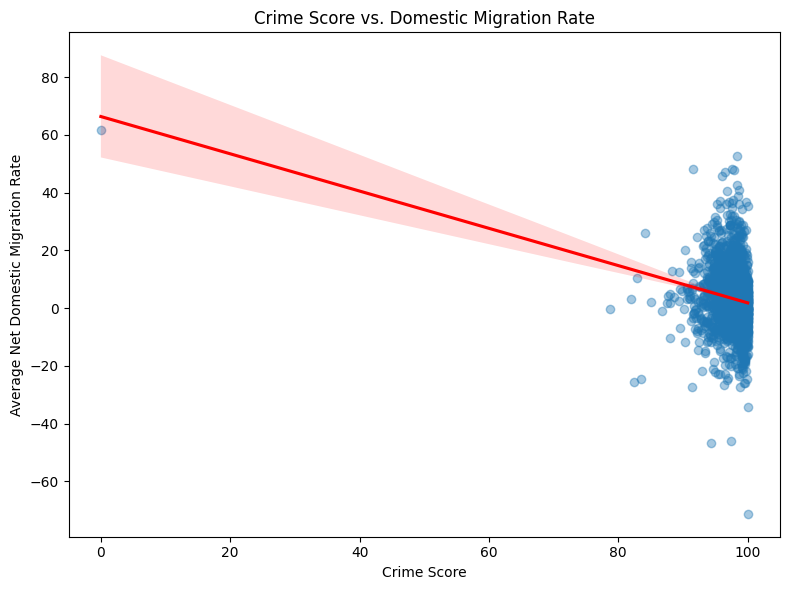

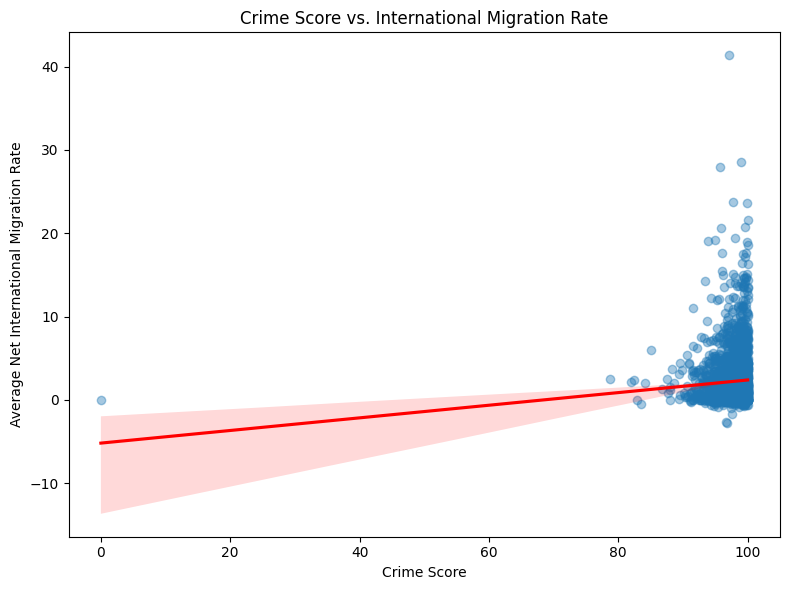

In [ ]:
import seaborn as sns

# Domestic migration
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=validation_df, x='Crime Score', y='avg_net_domestic_migration_rate',
    scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=ax
)
ax.set_title("Crime Score vs. Domestic Migration Rate")
ax.set_xlabel("Crime Score")
ax.set_ylabel("Average Net Domestic Migration Rate")
plt.tight_layout(); plt.show()

# International migration
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=validation_df, x='Crime Score', y='avg_net_international_migration_rate',
    scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=ax
)
ax.set_title("Crime Score vs. International Migration Rate")
ax.set_xlabel("Crime Score")
ax.set_ylabel("Average Net International Migration Rate")
plt.tight_layout(); plt.show()